<a href="https://colab.research.google.com/github/shivamkumar359/Pneumonia_detection/blob/main/notebook/pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [9]:
import os
# List the contents of the downloaded dataset path
print(f"Contents of {path}:")

for dirname,_, filenames in os.walk(path):
  for filename in filenames:
    print(os.path.join(dirname,filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person629_bacteria_2509.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person952_bacteria_2877.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1315_virus_2270.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1392_bacteria_3538.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person475_bacteria_2025.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1288_bacteria_3251.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1005_virus_1688.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person442_virus_900.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person755_bacteria_2659.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person655_bacteria_2547.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray

In [10]:
import os

# Define the base directory for the images
base_dir = os.path.join(path, 'chest_xray', 'chest_xray')

# Define categories (train, val, test) and classes (NORMAL, PNEUMONIA)
categories = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

# Dictionary to store image counts
image_counts = {}

# Iterate through categories and classes to count images
for category in categories:
    image_counts[category] = {}
    for cls in classes:
        dir_path = os.path.join(base_dir, category, cls)
        if os.path.exists(dir_path):
            # Filter for actual image files (e.g., .jpeg, .png, etc.)
            count = len([name for name in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, name)) and not name.startswith('.')])
            image_counts[category][cls] = count
        else:
            image_counts[category][cls] = 0

# Print the counts
print("Image counts per category and class:")
for category, classes_data in image_counts.items():
    print(f"\nCategory: {category.upper()}")
    for cls, count in classes_data.items():
        print(f"  {cls}: {count} images")


Image counts per category and class:

Category: TRAIN
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

Category: VAL
  NORMAL: 8 images
  PNEUMONIA: 8 images

Category: TEST
  NORMAL: 234 images
  PNEUMONIA: 390 images


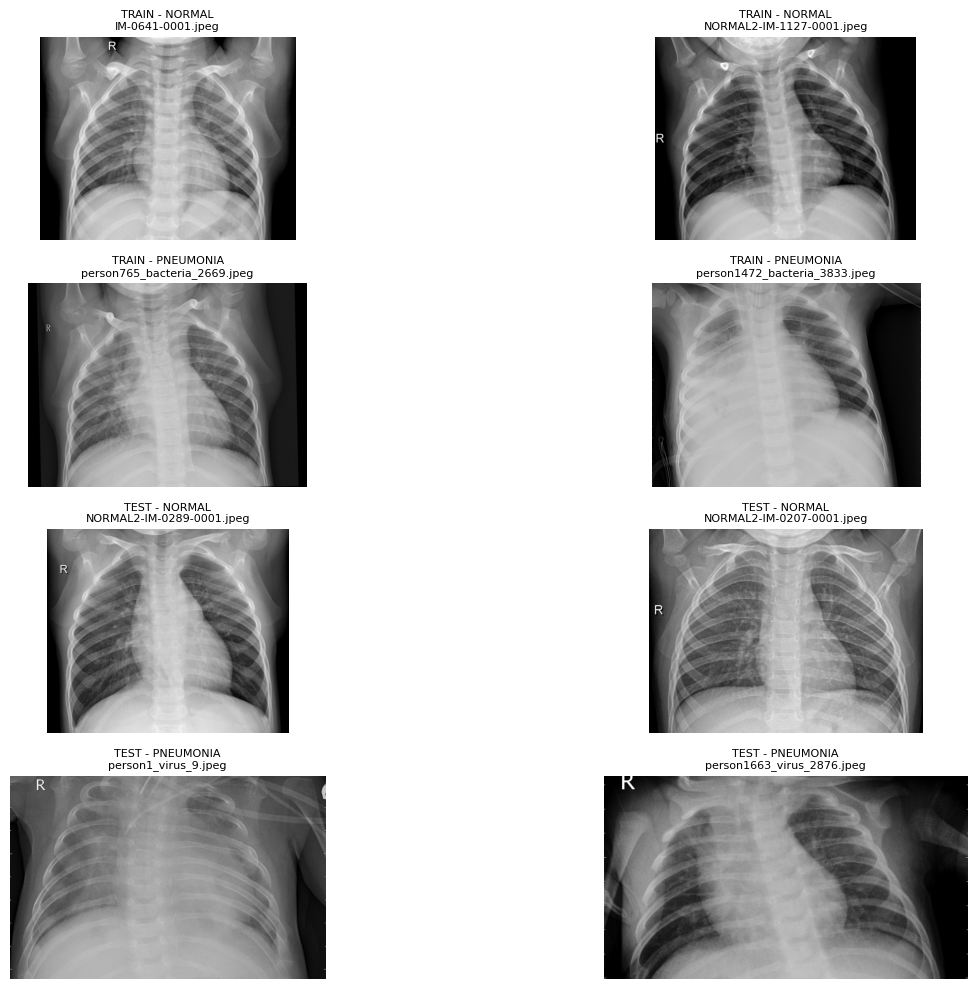

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Function to display sample images
def display_sample_images(base_dir, categories, classes, num_samples_per_class=2):
    plt.figure(figsize=(15, 10))
    plot_index = 1

    for category in categories:
        for cls in classes:
            dir_path = os.path.join(base_dir, category, cls)
            if os.path.exists(dir_path):
                # Get all image files, excluding hidden files like .DS_Store
                images = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)) and not f.startswith('.')]

                if images:
                    # Randomly select a few images
                    sample_images = random.sample(images, min(len(images), num_samples_per_class))

                    for img_name in sample_images:
                        img_path = os.path.join(dir_path, img_name)
                        img = mpimg.imread(img_path)

                        plt.subplot(len(categories) * len(classes), num_samples_per_class, plot_index)
                        plt.imshow(img, cmap='gray') # X-ray images are usually grayscale
                        plt.title(f'{category.upper()} - {cls}\n{img_name}', fontsize=8)
                        plt.axis('off')
                        plot_index += 1
                else:
                    print(f"No images found in {dir_path}")
            else:
                print(f"Directory not found: {dir_path}")

    plt.tight_layout()
    plt.show()

# Display sample images from TRAIN and TEST categories for both classes
display_sample_images(base_dir, ['train', 'test'], classes, num_samples_per_class=2)


In [12]:
!pip install -q tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
img_width, img_height = 150, 150  # Common dimensions for image classification
batch_size = 32

# Define paths for train and test sets
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
# The original 'val_dir' will no longer be used directly as we will create validation split from train_dir

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================
# Training Data Augmentation (with validation split)
# =========================

# For training, we apply data augmentation and set aside a validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% of training data will be used for validation
)
print("Training data has been modified ")

Training data has been modified 


In [14]:
# =========================
# Test Data Rescaling
# =========================

# For test sets, only rescaling is needed
test_datagen = ImageDataGenerator(
    rescale=1./255
)
print("Testing data rescaling has been modified ")

Testing data rescaling has been modified 


In [15]:
# =========================
# Training Generator
# =========================

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='training', # Specify this as the training subset
    shuffle=True
)
print("Training generator has been created ")

Found 4173 images belonging to 2 classes.
Training generator has been created 


In [16]:
# =========================
# Validation Generator
# =========================

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation', # Specify this as the validation subset
    shuffle=False # No need to shuffle validation data
)
print("validation has been modified ")

Found 1043 images belonging to 2 classes.
validation has been modified 


In [17]:
# =========================
# Test Generator
# =========================

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

Found 624 images belonging to 2 classes.


## Improving Model Accuracy with Transfer Learning

As discussed, to further enhance the model's performance, we will leverage Transfer Learning. This technique involves using a pre-trained neural network (a model that has already been trained on a massive dataset like ImageNet) and adapting it to our specific task. The pre-trained model has learned to recognize a wide variety of features from images, and these learned features can be incredibly useful for new, related tasks like medical image classification, even with smaller datasets.

We will use MobileNetV2 as the base of our new model. We'll add our own classification layers on top of this pre-trained base, allowing the model to learn the specific nuances of pneumonia detection while benefiting from the powerful feature extraction capabilities of the pre-trained network.

In [18]:
from tensorflow.keras.applications import MobileNetV2 # You can choose other models like VGG16, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the pre-trained MobileNetV2 model, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Freeze the layers of the base model to prevent them from being updated during training
# This preserves the learned features from ImageNet
base_model.trainable = False

# Create a new model on top of the pre-trained base
x = base_model.output
x = GlobalAveragePooling2D()(x) # Add a Global Average Pooling layer
x = Dense(128, activation='relu')(x) # Add a new dense layer
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Combine the base model and our new layers
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the new model with an appropriate learning rate
transfer_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

transfer_model.summary()

/tmp/ipykernel_1413/740239409.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
import numpy as np
# 3. Define Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)
# Train with the callback
epochs = 15

history = transfer_model.fit(
    train_generator,

    steps_per_epoch=int(
        np.ceil(
            train_generator.samples /
            train_generator.batch_size
        )
    ),

    epochs=epochs,

    validation_data=validation_generator,

    validation_steps=int(
        np.ceil(
            validation_generator.samples /
            validation_generator.batch_size
        )
    ),

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 920ms/step - accuracy: 0.8138 - loss: 0.4103 - val_accuracy: 0.8859 - val_loss: 0.2532 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 680ms/step - accuracy: 0.8917 - loss: 0.2603 - val_accuracy: 0.9156 - val_loss: 0.2079 - learning_rate: 1.0000e-04
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 672ms/step - accuracy: 0.9137 - loss: 0.2138 - val_accuracy: 0.9185 - val_loss: 0.1966 - learning_rate: 1.0000e-04
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 678ms/step - accuracy: 0.9171 - loss: 0.2056 - val_accuracy: 0.9425 - val_loss: 0.1719 - learning_rate: 1.0000e-04
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 673ms/step - accuracy: 0.9190 - loss: 0.1996 - val_accuracy: 0.9367 - val_loss: 0.1722 - learning_rate: 1.0000e-04
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 672ms/step - accuracy: 0.9212 - loss: 0.1871 - val_accuracy: 0.9434 - val_loss: 0.1638 - learning_rate: 1.0000e-04
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 6

In [20]:
loss, accuracy = transfer_model.evaluate(
    validation_generator
)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 534ms/step - accuracy: 0.9434 - loss: 0.1435
Validation Loss: 0.14349381625652313
Validation Accuracy: 0.9434323906898499


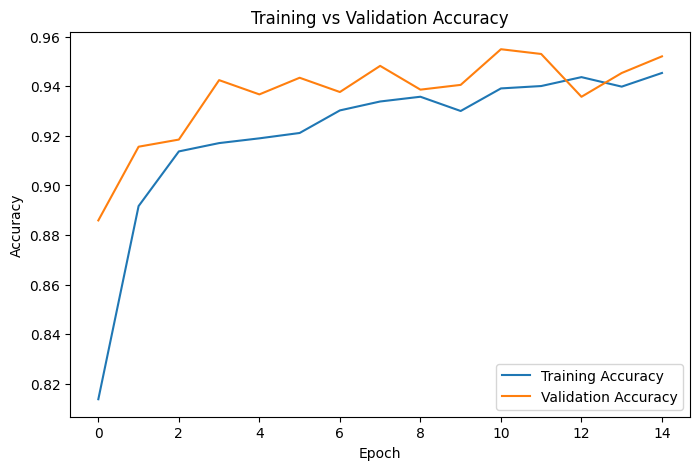

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()

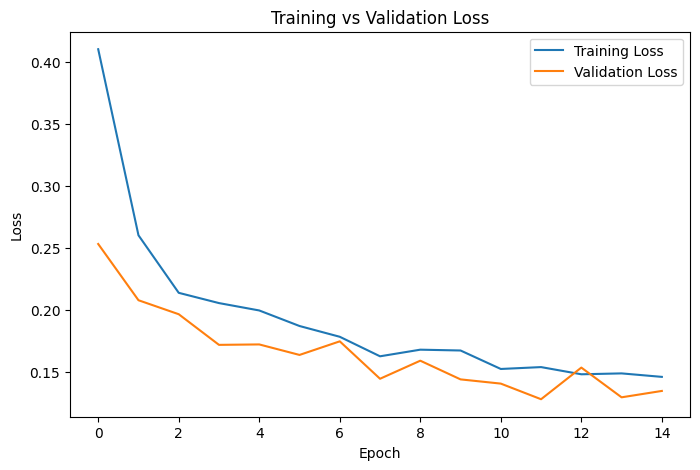

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()


In [23]:
transfer_model.save('improved_cnn_model.h5')

print("Model saved successfully!")

Model saved successfully!


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 536ms/step - accuracy: 0.8750 - loss: 0.2832
Test Loss: 0.2832
Test Accuracy: 0.8750
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 442ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.74      0.82       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



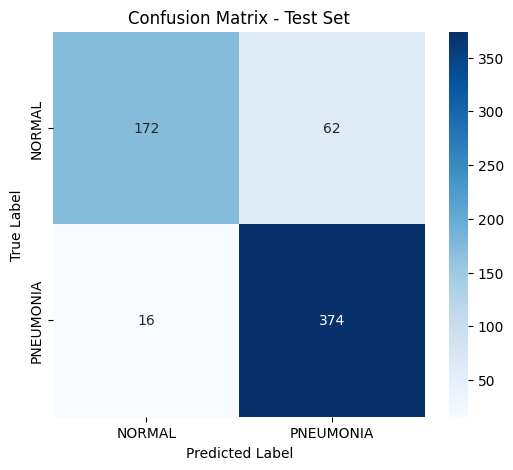

In [24]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on the test set
test_loss, test_accuracy = transfer_model.evaluate(test_generator, steps=int(np.ceil(test_generator.samples / test_generator.batch_size)))
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict probabilities
test_generator.reset()
predictions = transfer_model.predict(test_generator, steps=int(np.ceil(test_generator.samples / test_generator.batch_size)))

# Convert probabilities to binary class predictions (0 or 1)
y_pred = (predictions > 0.5).astype(int).flatten()

# Get true labels
y_true = test_generator.classes

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_generator.class_indices.keys()), yticklabels=list(test_generator.class_indices.keys()))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.show()


In [25]:
!pip install -q gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.4/144.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.6 MB/s eta 0:00:00


In [30]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_pneumonia(img):
    # Re-verify and resize the image to match model input
    img = img.resize((img_width, img_height))
    img_array = image.img_to_array(img)

    # Normalize the pixel values
    img_array = img_array / 255.0

    # Expand dimensions to fit (1, 150, 150, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Perform prediction
    prediction = transfer_model.predict(img_array)[0][0]

    # Format output labels and confidence score
    if prediction > 0.5:
        confidence = prediction * 100
        label = "PNEUMONIA "
        color = "red"
    else:
        confidence = (1 - prediction) * 100
        label = "NORMAL "
        color = "green"

    return f"Expected announcement: {label}\nConfidence level: {confidence:.2f}%"

# Create Custom Gradio Interface
interface = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil", label="(Upload Chest X-Ray)"),
    outputs=gr.Textbox(label="(Prediction Output)"),
    title="Smart Pneumonia Detection System 🫁",
    description="Upload a chest X-ray and the trained AI model will analyse it immediately to determine whether it is normal or shows signs of pneumonia.",
    theme="soft"
)

# Launch Interface with a shareable public link
interface.launch(share=True, debug=True)

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://32ed1952c61d74541a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/gradio/queueing.py", line 848, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/gradio/route_utils.py", line 417, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<12 lines>...
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/gradio/blocks.py", line 2698, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<9 lines>...
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/gradio/blocks.py", line 1963, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        fn, *processed_input, limiter=self.limiter
        ^^^^^^^^^^^^^^

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://32ed1952c61d74541a.gradio.live


In [ ]:
s